In [2]:
 #🎓 Predicting Student Mental Health Score from Social Media Usage

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Student Social Media And Mental Health Impact.csv")

In [5]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [9]:
# Exploratory Data Analysis (EDA)

<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

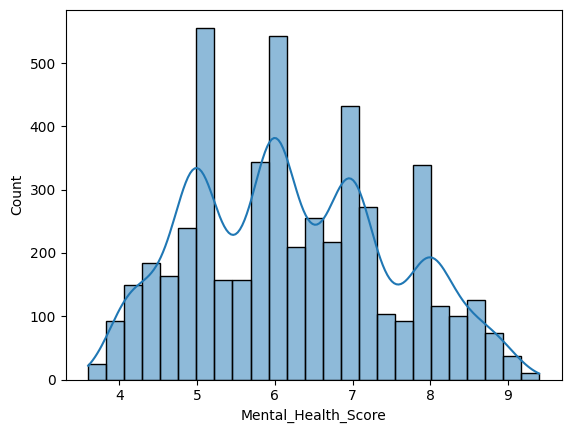

In [10]:
sns.histplot(df["Mental_Health_Score"],kde=True)

<Axes: >

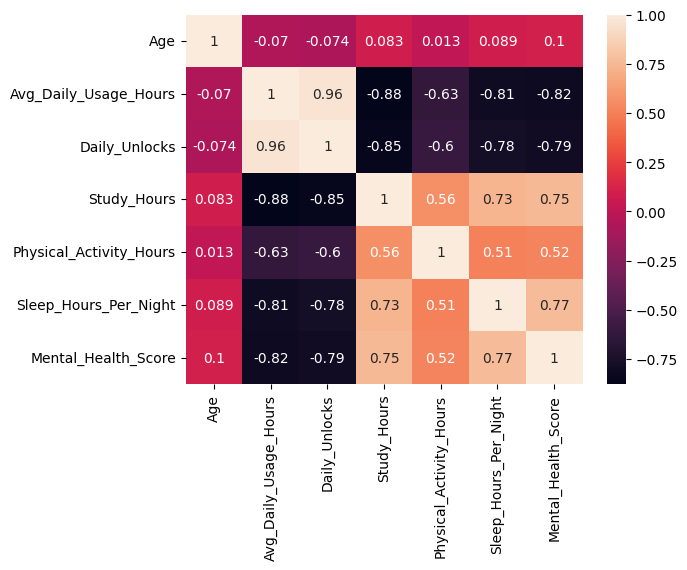

In [11]:
sns.heatmap(df.corr(numeric_only=True),annot=True)


In [12]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='object')

In [13]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

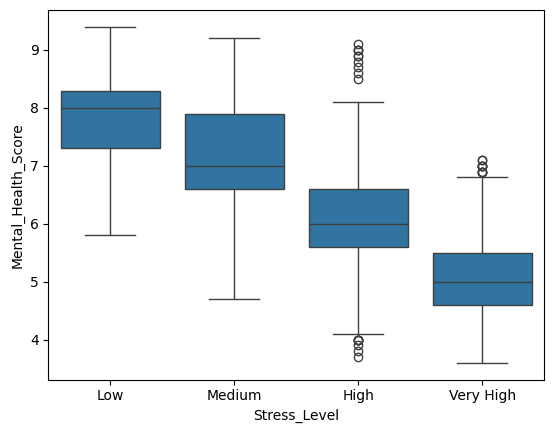

In [14]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score',data=df, order=order)

<Axes: xlabel='Study_Hours', ylabel='Mental_Health_Score'>

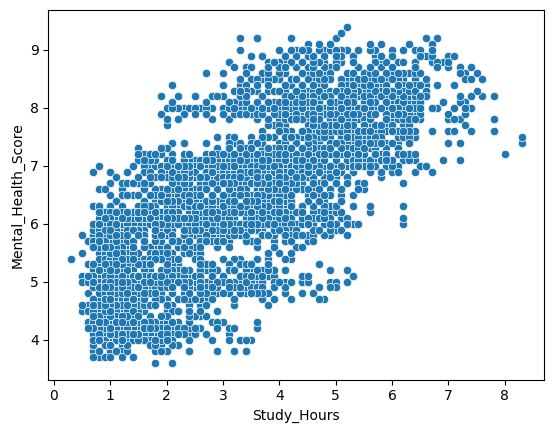

In [15]:
sns.scatterplot(x="Study_Hours", y="Mental_Health_Score", data=df)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

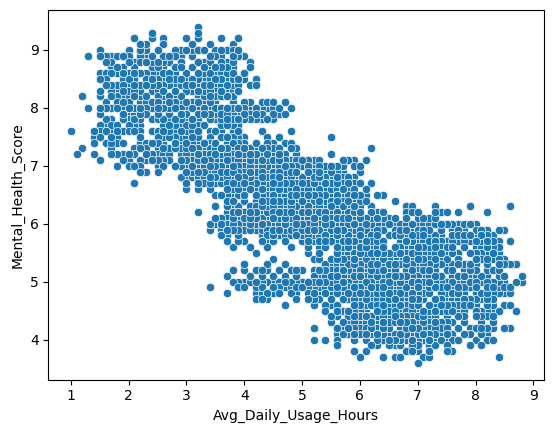

In [16]:

sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score',data=df)

In [17]:
df['Most_Used_Platform'].value_counts()

,count
Most_Used_Platform,
Instagram,1130
TikTok,918
Facebook,719
LinkedIn,523
YouTube,491
Twitter,462
Snapchat,420
WhatsApp,175
LINE,50


<Axes: xlabel='Most_Used_Platform', ylabel='count'>

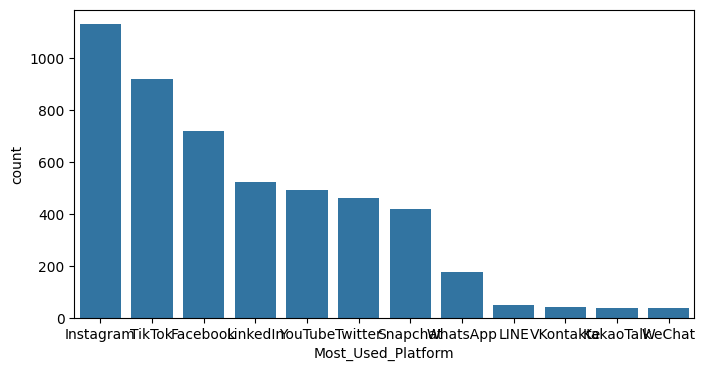

In [18]:

plt.figure(figsize=(8, 4))
sns.countplot(x=df['Most_Used_Platform'], order=df['Most_Used_Platform'].value_counts().index)


In [19]:
 # cheking outliers

In [20]:
num_features = df.select_dtypes(include='number') #int64 or float64
Q1  = num_features.quantile(0.25)
Q3  = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


In [21]:
# Data Cleaning

In [22]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [23]:
df = df.drop_duplicates()

#2. Converting negative or unrealitstic value to realistic value
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)


In [24]:
# skewness checking

In [25]:
num_cols = df.select_dtypes(include='number')
num_cols.skew()
# near to 0 -> Centralized (0.01, 0.002)
# negative -> Left Skewed (-1.56)
# poistive (greater than 0) -> Right Skewed (1.256)


,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [26]:
# feature engineering

In [27]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [28]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [46]:
df['Grouped_country'] = df['Country'].apply(group_countries)

In [49]:
df['Grouped_country'].value_counts()

,count
Grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [50]:
# Train test split

In [51]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Group_Countries',
       'Group_countries', 'Grouped_countries', 'Grouped_country'],
      dtype='object')

In [52]:
from sklearn.model_selection import train_test_split

skwewd_col         = ['Study_Hours']
other_numeric_cols = ["Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks","Physical_Activity_Hours",
                      "Sleep_Hours_Per_Night"]
ordinal_col        = ['Stress_Level']
normal_col         = ["Gender", "Academic_Level", "Most_Used_Platform", "Purpose_Of_Use", "Grouped_country"]


feature_col = skwewd_col + other_numeric_cols + ordinal_col + normal_col

X = df[feature_col]
y = df['Mental_Health_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)


In [53]:
 # Preprocessing using ColumnTransformer

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
#1. Skewed features

skew_pipline = Pipeline(steps=[
  ('log_transform', FunctionTransformer(np.log1p)),
     ('scaler',StandardScaler())
])

#2. Numeric Features

numeric_pipline = Pipeline(steps=[
    ('scaler',StandardScaler())
])

#3. Ordinal

ordinal_pipline = Pipeline(steps=[
    ('ordinal_encoder', OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']]))
])

#4. Nominal Features

nominal_pipline = Pipeline(steps=[
    ('one_hot_encoder', OneHotEncoder(handle_unknown='ignore'))
])


# columntransfer

preprocessor = ColumnTransformer(transformers=[
    ('skew_pipline', skew_pipline, skwewd_col),
    ('numeric_pipline', numeric_pipline, other_numeric_cols),
    ('ordinal_pipline', ordinal_pipline, ordinal_col),
    ('nominal_pipline', nominal_pipline, normal_col)
])


In [60]:
# pipeline and model building

In [62]:
# linear regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds       = lr_pipeline.predict(X_test)
lr_preds_train = lr_pipeline.predict(X_train)

lr_r2_testing  = r2_score(y_test, lr_preds)
lr_r2_training = r2_score(y_train, lr_preds_train)
lr_mae         = mean_absolute_error(y_test, lr_preds)

print(f"Accuracy of Training {lr_r2_training}")
print(f"Accuracy of Testing {lr_r2_testing}")
print(f'MAE {lr_mae}')

Accuracy of Training 0.7236771199387538
Accuracy of Testing 0.739794461743302
MAE 0.5361775634720183


In [68]:
# Random forest

from sklearn.ensemble import RandomForestRegressor

rf_pipeline = rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor())
])

rf_pipeline.fit(X_train, y_train)
rf_preds       = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)


rf_r2_testing  = r2_score(y_test, rf_preds)
rf_r2_training = r2_score(y_train, rf_preds_training)
rf_mae         = mean_absolute_error(y_test, rf_preds)

print(f"Accuracy of Training {rf_r2_training}")
print(f"Accuracy of Testing {rf_r2_testing}")
print(f"MAE : {rf_mae}")

Accuracy of Training 0.9812591770411401
Accuracy of Testing 0.8777513876177152
MAE : 0.3479088666666667


In [69]:
# Hyperparameter Tuning the Random Forest

In [71]:
from sklearn.model_selection import RandomizedSearchCV

# The step name in rf_pipeline is 'model', so we use model__ as prefix
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"Best Parameters: {random_search.best_params_}")
print(f"Best CV Score (R2): {random_search.best_score_}")

Best Parameters: {'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 15}
Best CV Score (R2): 0.8396778318921951


In [72]:
random_search.best_params_


{'model__n_estimators': 300,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 2,
 'model__max_depth': 15}

In [73]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds    = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8656638186297582
MAE Score for random forest after hyperparameter tuning 0.3685410176449163


In [74]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)

                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.877751     0.981259  0.347909  0.463373
2    Random Forest (tuned)  0.865664     0.954583  0.368541  0.485742


In [75]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']